In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from destripe import destripe
from destripe.adaptive import estimate_adaptive_params, estimate_tile_mus
from destripe.preprocess import prepare_solver_gray, rgb_to_luma

PROCESS_SIZE = 512
ADAPTIVE_LEVEL = 2
TILES = 2
VERBOSE = False

img = np.array(Image.open(ROOT / "asset" / "sample_01.jpeg"))
out = destripe(
    img,
    adaptive=ADAPTIVE_LEVEL,
    process_size=PROCESS_SIZE,
    iterations=1000,
    tiles=TILES,
    verbose=VERBOSE,
)


In [2]:
normalized = img.astype(np.float64)
normalized = (normalized - normalized.min()) / (normalized.max() - normalized.min())

if normalized.ndim == 2:
    gray = normalized
elif normalized.ndim == 3 and normalized.shape[2] == 3:
    gray = rgb_to_luma(normalized)
else:
    gray = normalized[..., 0]

solver_gray = prepare_solver_gray(gray=gray, process_size=PROCESS_SIZE)
params = estimate_adaptive_params(solver_gray, level=ADAPTIVE_LEVEL)
tile_mus = estimate_tile_mus(
    gray=solver_gray,
    tiles=TILES,
    level=ADAPTIVE_LEVEL,
    directions=params.directions,
)

print(f"directions: {params.directions}")
print(f"global mu1: {params.mu1:.6g}")
print(f"global mu2: {params.mu2:.6g}")
print(f"confidence: {params.confidence:.3f}")

if tile_mus:
    tile_mu_grid = np.array(tile_mus).reshape(TILES, TILES, 2)
    print("tile mu1:")
    print(tile_mu_grid[..., 0])
    print("tile mu2:")
    print(tile_mu_grid[..., 1])


directions: (0, 4)
global mu1: 0.25
global mu2: 0.01
confidence: 0.233
tile mu1:
[[0.25 0.25]
 [0.25 0.25]]
tile mu2:
[[0.01150372 0.01233593]
 [0.01040453 0.01045183]]


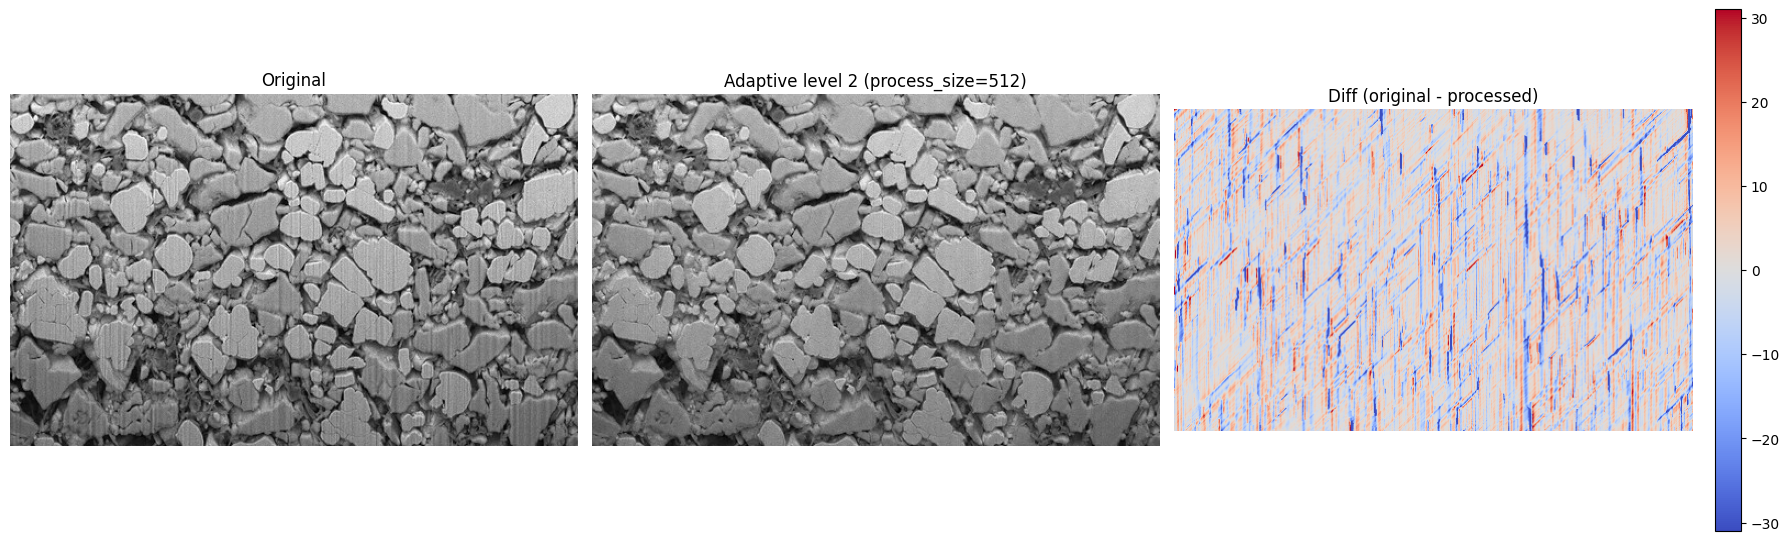

In [3]:
def make_luma(image):
    array = np.asarray(image, dtype=np.float64)
    if array.ndim == 3 and array.shape[2] == 3:
        return rgb_to_luma(array)
    if array.ndim == 3:
        return array[..., 0]
    return array


diff = make_luma(img) - make_luma(out)
diff_limit = np.percentile(np.abs(diff), 99)
if diff_limit == 0:
    diff_limit = 1

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img, cmap="gray" if img.ndim == 2 else None)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(out, cmap="gray" if out.ndim == 2 else None)
axes[1].set_title(f"Adaptive level {ADAPTIVE_LEVEL} (process_size={PROCESS_SIZE})")
axes[1].axis("off")
diff_plot = axes[2].imshow(
    diff,
    cmap="coolwarm",
    vmin=-diff_limit,
    vmax=diff_limit,
)
axes[2].set_title("Diff (original - processed)")
axes[2].axis("off")
fig.colorbar(diff_plot, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
